In [109]:
import torch
import matplotlib.pyplot as plt
import numpy as np


In [110]:
def plot_curvatures_single_figure(base_path, file_paths, labels, save_path):
    n_files = len(file_paths)
    # Load latent curvatures
    latent_curvatures = []
    for path in file_paths:
        data = torch.load(base_path + path, weights_only=False)
        latent_curvatures.append(data['curvatures_sub'][6])
    
    # Load angles and true curvature
    reference_data = torch.load(base_path + file_paths[0], weights_only=False)
    angles = reference_data['curvatures_sub'][0]
    true_curvature = reference_data['curvatures_sub'][5]
    
    # Labels and colors
    labels_list = [f'Learned Curv. {label}' for label in labels]
    colors = ['tab:blue', 'tab:orange', 'tab:red', 'tab:purple']
    
    # Plot all on one axis
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot true curvature in green
    ax.plot(angles, true_curvature, label='True Curv.', color='green', linestyle='--', linewidth=2)
    
    # Plot latent curvatures
    for i in range(n_files):
        ax.plot(angles, latent_curvatures[i], label=labels_list[i], color=colors[i], linewidth=2, alpha=0.8)
    
    # Formatting
    ax.set_xlabel('Angle')
    ax.set_ylabel('Curvature')
    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'])
    ax.grid(False)
    ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def round_to_half(x, up=False):
    return np.ceil(x * 2) / 2 if up else np.floor(x * 2) / 2


def compute_three_tick_positions(min_val, max_val):
    min_ = round_to_half(min_val)
    max_ = round_to_half(max_val, up=True)
    mid = round_to_half((min_ + max_) / 2)
    return [min_, mid, max_]


def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    safe_denom = np.where(denominator == 0, 1e-8, denominator)
    return 100 * np.mean(np.abs(y_pred - y_true) / safe_denom)


def plot_curvatures_stacked(base_path, file_paths, labels, save_path):
    n_files = len(file_paths)
    learned_curvatures = []

    # Load angles and true curvature
    ref_data = torch.load(os.path.join(base_path, file_paths[0]), weights_only=False)
    angles = ref_data['curvatures_sub'][0].numpy()
    true_curvature = ref_data['curvatures_sub'][5].numpy()

    # Load all learned curvatures
    for path in file_paths:
        data = torch.load(os.path.join(base_path, path), weights_only=False)
        learned_curvatures.append(data['curvatures_sub'][6].numpy())

    # Global y-limits and ticks
    all_curvs = [true_curvature] + learned_curvatures
    y_min = min(c.min() for c in all_curvs)
    y_max = max(c.max() for c in all_curvs)
    yticks = compute_three_tick_positions(y_min, y_max)

    fig, axes = plt.subplots(nrows=n_files, ncols=1, figsize=(6, 2 * n_files), sharex=True)
    if n_files == 1:
        axes = [axes]

    tab10 = list(plt.cm.tab10.colors)
    tab10.pop(2)  # remove green
    color_cycle = tab10

    for i, (ax, learned, label) in enumerate(zip(axes, learned_curvatures, labels)):
        ax.plot(angles, true_curvature, label='True Curvature', color='green', linestyle='--', linewidth=2)
        ax.plot(angles, learned, label=f'Learned Curv. {label}', color=color_cycle[i % len(color_cycle)], linewidth=1.8)

        # Metrics
        mse_val = np.mean((learned - true_curvature) ** 2)
        smape_val = smape(true_curvature, learned)
        ax.text(0.01, 0.95, f"MSE = {mse_val:.2f}\nSMAPE = {smape_val:.2f}%",
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor='white', edgecolor='gray', alpha=0.8))

        ax.set_ylim(yticks[0], yticks[2])
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{t:.1f}" if t % 1 else f"{int(t)}" for t in yticks])
        ax.set_ylabel('Curvature', fontsize=10)
        ax.legend(loc='upper right', fontsize=8)

        if i == n_files - 1:
            ax.set_xlabel('Angle', fontsize=10)
            ax.set_xticks([0, np.pi, 2 * np.pi])
            ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'])
        else:
            ax.set_xticklabels([])

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()



# M-VAE Flower - Impact Topo Loss
Compare $\beta=0.08$, $\gamma\in[0,1,100]$

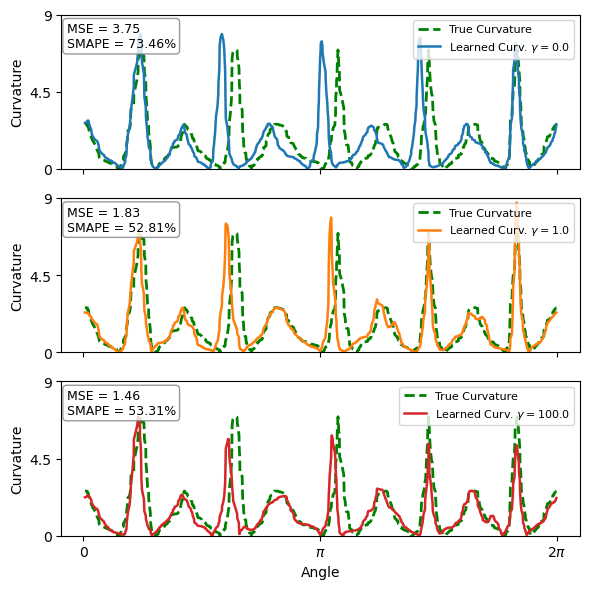

In [111]:
base_path = "../OLD_notebooks_m_vae/curvatures/"
file_paths = [
    "curvatures_exp01_flower_topo_VAE_100epochs.pt",
    "curvatures_exp04_flower_topo_VAE_100epochs.pt",
    "curvatures_exp07_flower_topo_VAE_100epochs.pt",
]
labels = [r"$\gamma=0.0$", r"$\gamma=1.0$", r"$\gamma=100.0$"]
save_path = "plots/m_vae_flower_impact_ltopo_008.png"

plot_curvatures_stacked(base_path, file_paths, labels, save_path)


Compare $\beta\in[0,0.08,1]$, $\gamma=0$

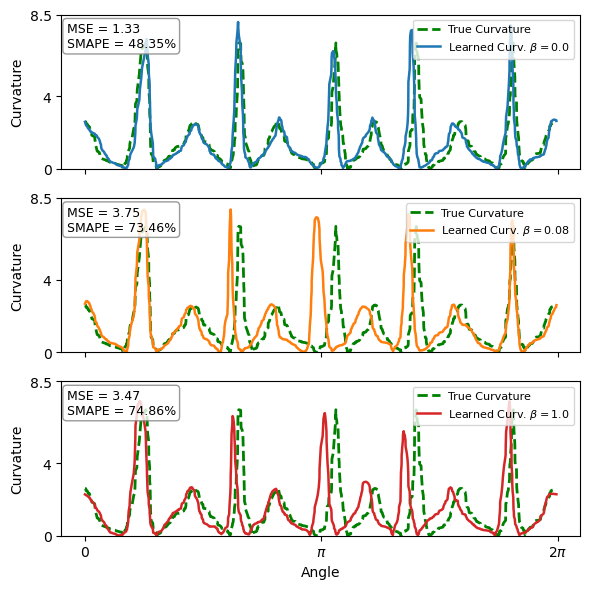

In [112]:
base_path = "../OLD_notebooks_m_vae/curvatures/"
file_paths = [
    "curvatures_exp00_flower_topo_VAE_100epochs.pt",
    "curvatures_exp01_flower_topo_VAE_100epochs.pt",
    "curvatures_exp02_flower_topo_VAE_100epochs.pt",
]
labels = [r"$\beta=0.0$", r"$\beta=0.08$", r"$\beta=1.0$"]
save_path = "plots/m_vae_flower_impact_lkl_gamma0.png"

plot_curvatures_stacked(base_path, file_paths, labels, save_path)


# M-VAE Scrunchy - Impact Topo Loss
Compare $\beta=0.08$, $\gamma\in[0,1,100]$

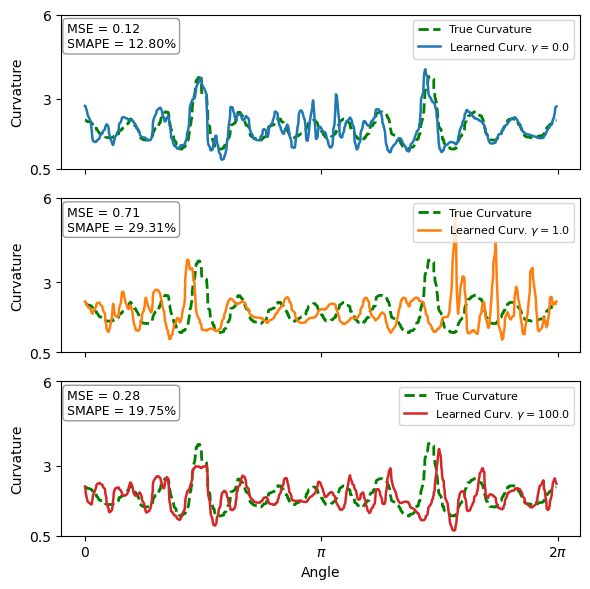

In [113]:
base_path = "../OLD_notebooks_m_vae/curvatures/"
file_paths = [
    "curvatures_exp01_scrunchy_VAE_w100_100epochs.pt",
    "curvatures_exp04_scrunchy_VAE_w100_100epochs.pt",
    "curvatures_exp07_scrunchy_VAE_w100_100epochs.pt",
]
labels = [r"$\gamma=0.0$", r"$\gamma=1.0$", r"$\gamma=100.0$"]
save_path = "plots/m_vae_scrunchy_impact_ltopo_beta008.png"

plot_curvatures_stacked(base_path, file_paths, labels, save_path)

Compare $\beta\in[0,0.08,1]$, $\gamma=0$

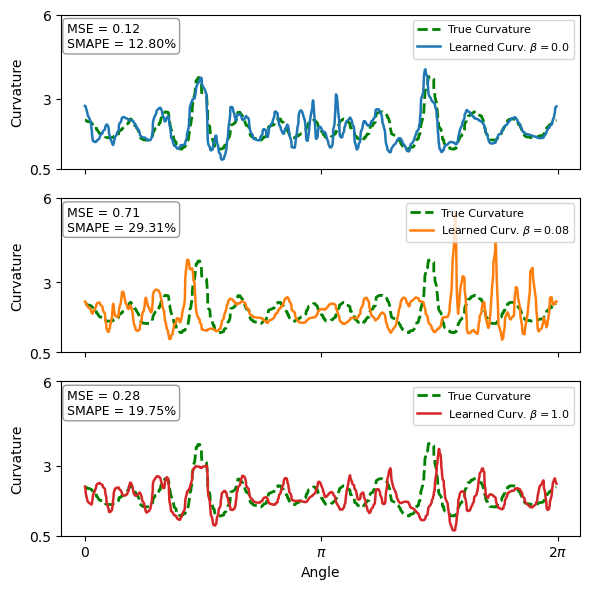

In [114]:
base_path = "../OLD_notebooks_m_vae/curvatures/"
file_paths = [
    "curvatures_exp01_scrunchy_VAE_w100_100epochs.pt",
    "curvatures_exp04_scrunchy_VAE_w100_100epochs.pt",
    "curvatures_exp07_scrunchy_VAE_w100_100epochs.pt",
]
labels = [r"$\beta=0.0$", r"$\beta=0.08$", r"$\beta=1.0$"]
save_path = "plots/m_vae_scrunchy_impact_lkl_gamma0.png"

plot_curvatures_stacked(base_path, file_paths, labels, save_path)

# Euclidean AE - Flower
$\alpha

In [ ]:
base_path = "../OLD_notebooks_m_vae/curvatures/"
file_paths = [
    "curvatures_exp01_flower_topo_VAE_100epochs.pt",
    "curvatures_exp04_flower_topo_VAE_100epochs.pt",
    "curvatures_exp07_flower_topo_VAE_100epochs.pt",
]
labels = [r"$\gamma=0.0$", r"$\gamma=1.0$", r"$\gamma=100.0$"]
save_path = "plots/m_vae_flower_impact_ltopo_008.png"

plot_curvatures_stacked(base_path, file_paths, labels, save_path)